# H2 — node2vec embeddings for the ATC similarity graphs

## Purpose
Turns the two graphs built in [`network_generation.ipynb`](./network_generation.ipynb) (`adverse_atc.graphml`, `non_interacting_atc.graphml`) into fixed-length node embeddings using **node2vec**: it simulates biased random walks over each graph, then feeds those walks into a skip-gram (`word2vec`)-style model, so that drugs with similar network neighborhoods end up with similar embedding vectors.

## Environment note
This environment now has both `pecanpy` and `gensim` installed and working, so `src/node2vec_utils.py` runs node2vec via `pecanpy`'s `SparseOTF` random-walk simulator + gensim's `Word2Vec` for the skip-gram training -- no compatibility shims needed. See [`../NODE2VEC_ENV_NOTES.md`](../NODE2VEC_ENV_NOTES.md) for the environment history.

## Pipeline
1. Load `adverse_atc.graphml` / `non_interacting_atc.graphml`.
2. Set node2vec hyperparameters.
3. Run node2vec on each graph.
4. Sanity-check the embeddings (shape, a PCA scatter, nearest-neighbor spot check).
5. Save embeddings to `embeddings/{dataset}_atc_node2vec.parquet`.

## Glossary (plain-English definitions)

- **node2vec:** An algorithm that converts each node in a graph into a list of numbers (an *embedding*) by simulating many random walks starting from that node, then training a `word2vec`-style model to predict "which nodes tend to co-occur on the same walk" -- nodes that show up in similar neighborhoods end up with similar vectors.
- **Random walk:** Starting at a node, repeatedly hop to a random neighbor (weighted by edge weight) for a fixed number of steps, recording the sequence of nodes visited.
- **`p` (return parameter):** Controls how likely the walk is to immediately backtrack to the node it just came from. Higher `p` = less backtracking = more exploration.
- **`q` (in-out parameter):** Controls whether the walk prefers to stay close to the start node (behaving like breadth-first search, good for capturing local community structure) or wander further away (behaving like depth-first search, good for capturing structural roles). `q < 1` encourages wandering; `q > 1` encourages staying local.
- **`dimensions`:** The length of each drug's output embedding vector.
- **`walk_length` / `num_walks`:** How many steps each random walk takes, and how many walks are started from each node -- more walks/longer walks means more training data for the embedding model but more runtime.
- **`window`:** The skip-gram context window -- how many neighbors on either side of a node *within a walk* count as "co-occurring" with it.
- **Embedding:** A fixed-length numeric vector summarizing a node's position/role in the graph, suitable as input to a downstream ML model (e.g. a DDI classifier that concatenates two drugs' embeddings).

## How node2vec actually works here, step by step

1. **Simulate random walks.** Starting from every drug (node), take `num_walks` separate walks of `walk_length` steps each. At each step, hop to a random neighbor -- the chance of picking any particular neighbor is proportional to that edge's weight, further biased by `p`/`q` (see Glossary above). The result is a big pile of walks, where each walk is just a list of drug IDs, e.g. `["DB00001", "DB00035", "DB00080", ...]`.
2. **Treat walks like sentences.** Feed all those walks into a `word2vec` skip-gram model exactly the way you'd feed it sentences of words -- it learns to predict "which nodes tend to appear near this one within a walk," using a sliding `window`. Nodes that keep showing up in similar walk-contexts end up with similar vectors.
3. **Read off the embeddings.** Once training finishes, each node's `dimensions`-length vector *is* its node2vec embedding -- ready to save and later feed into a downstream DDI classifier.

## `pecanpy` vs. the PyPI `node2vec` package

Both implement the same algorithm (Grover & Leskovec's biased 2nd-order random walks + skip-gram), but they differ in maintenance status and implementation:

| | PyPI `node2vec` (0.3.0) | `pecanpy` (used in this notebook) |
|---|---|---|
| Maintenance | Unmaintained since ~2020 | Actively maintained |
| Walk simulation | Pure Python + joblib | Numba-JIT-compiled (`@njit`) -- substantially faster |
| gensim compatibility | Calls `Word2Vec(size=..., iter=...)`, which **breaks** on gensim >= 4.0 (renamed to `vector_size`/`epochs`) unless patched | Calls `Word2Vec(vector_size=..., epochs=...)` -- works natively on gensim >= 4.0, no patching needed |
| Graph representations | One (dense per-node neighbor lists) | Several: `PreComp` (precomputes and caches 2nd-order transition probabilities -- fastest for repeated walks, but memory-heavy), `SparseOTF`/`DenseOTF` ("on the fly" -- recompute transition probabilities during the walk itself, trading a little CPU time for much lower memory use) |

We use pecanpy's **`SparseOTF`** variant because these graphs are sparse (relatively few edges per node relative to the total node count) -- `SparseOTF` stores the graph as a CSR sparse matrix internally rather than a dense one. Note: our current loader (`src/node2vec_utils.py`) still builds a dense adjacency matrix via `networkx.to_numpy_array` as an intermediate step before handing it to pecanpy, which is fine at this project's scale (thousands of nodes) but would need to switch to pecanpy's `read_edg` (which reads a sparse edge-list file directly, no dense intermediate) if a future graph grew into the tens/hundreds of thousands of nodes.

See [`../NODE2VEC_ENV_NOTES.md`](../NODE2VEC_ENV_NOTES.md) for the environment-setup history behind this choice.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from sklearn.decomposition import PCA

SRC_FOLDER = r"C:\Users\ashto\ddi-prediction\src"
if SRC_FOLDER not in sys.path:
    sys.path.append(SRC_FOLDER)

from node2vec_utils import run_node2vec, save_embeddings

NETWORK_DIR = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h2_pharmacological_similarity\networks")
EMBEDDING_DIR = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h2_pharmacological_similarity\embeddings")
EMBEDDING_DIR.mkdir(exist_ok=True)

## 1. Load the graphs

Both graphs are small enough (~1.9k nodes each) to embed with the original node2vec paper's default hyperparameters.

In [2]:
DATASETS = ["adverse", "non_interacting"]
LAYER = "atc"

graphs = {}
for dataset in DATASETS:
    G = nx.read_graphml(NETWORK_DIR / f"{dataset}_{LAYER}.graphml")
    graphs[dataset] = G
    print(f"{dataset:<16}: {G.number_of_nodes():>5} nodes, {G.number_of_edges():>7} edges")

adverse         :  1893 nodes,   13826 edges
non_interacting :  1893 nodes,    5031 edges


## 2. node2vec hyperparameters

These match the defaults recommended in the original node2vec paper (Grover & Leskovec, 2016). `p = q = 1` reduces node2vec to plain unbiased random walks (a good, neutral starting point) -- retune `p`/`q` later if you want to bias the walks toward local community structure (`q < 1`) or exploration (`q > 1`).

In [3]:
NODE2VEC_PARAMS = dict(
    dimensions=128,
    walk_length=80,
    num_walks=10,
    p=1.0,
    q=1.0,
    window=10,
    epochs=5,
    workers=1,  # raise if parallel walk generation works fine on your machine
    seed=42,
)

## 3. Run node2vec

Simulates the random walks and trains the skip-gram model for each graph. This is the slow step -- expect this to take longer than everything else in the notebook combined.

In [4]:
atc_embeddings = {}
for dataset, G in graphs.items():
    print(f"Running node2vec on {dataset}...")
    atc_embeddings[dataset] = run_node2vec(G, **NODE2VEC_PARAMS)
    print(f"  -> embeddings shape: {atc_embeddings[dataset].shape}")

Running node2vec on adverse...
  -> embeddings shape: (1893, 128)
Running node2vec on non_interacting...
  -> embeddings shape: (1893, 128)


## 4. Sanity checks

A quick visual/spot check -- not a rigorous evaluation (that belongs in the downstream DDI modeling notebook). We check that:
- Every node in the graph got an embedding row.
- A 2D PCA projection doesn't collapse everything to a single point (which would signal a degenerate/failed training run).
- A random drug's nearest neighbors in embedding space look at least plausible (share edges or similar degree) rather than arbitrary.

adverse         : 0 node(s) missing an embedding (expect 0)
non_interacting : 0 node(s) missing an embedding (expect 0)


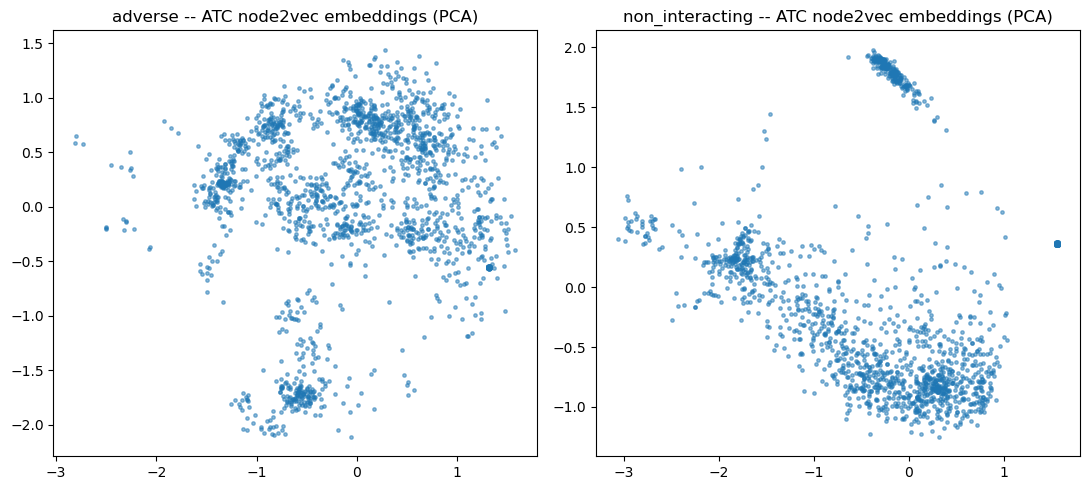

In [5]:
for dataset, G in graphs.items():
    n_missing = G.number_of_nodes() - atc_embeddings[dataset].shape[0]
    print(f"{dataset:<16}: {n_missing} node(s) missing an embedding (expect 0)")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (dataset, emb) in zip(axes, atc_embeddings.items()):
    coords = PCA(n_components=2, random_state=42).fit_transform(emb.values)
    ax.scatter(coords[:, 0], coords[:, 1], s=6, alpha=0.5)
    ax.set_title(f"{dataset} -- ATC node2vec embeddings (PCA)")
plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

dataset_to_check = "adverse"
G = graphs[dataset_to_check]
emb = atc_embeddings[dataset_to_check]

sample_node = max(G.degree, key=lambda x: x[1])[0]  # pick a well-connected node so its neighbors are informative
sims = cosine_similarity(emb.loc[[sample_node]], emb).flatten()
nearest = pd.Series(sims, index=emb.index).drop(sample_node).sort_values(ascending=False).head(5)

sample_name = G.nodes[sample_node].get("name", sample_node)
print(f"Nearest embedding neighbors of {sample_node} ({sample_name}):")
for neighbor_id, sim in nearest.items():
    is_graph_neighbor = G.has_edge(sample_node, neighbor_id)
    neighbor_name = G.nodes[neighbor_id].get("name", neighbor_id)
    print(f"  {neighbor_id} ({neighbor_name}): cosine_sim={sim:.3f}, direct graph edge={is_graph_neighbor}")

Nearest embedding neighbors of DB21667 (Sevabertinib):
  DB11652 (Tucatinib): cosine_sim=0.912, direct graph edge=True
  DB11828 (Neratinib): cosine_sim=0.904, direct graph edge=True
  DB12015 (Alpelisib): cosine_sim=0.902, direct graph edge=True
  DB18762 (Zongertinib): cosine_sim=0.898, direct graph edge=True
  DB12001 (Abemaciclib): cosine_sim=0.894, direct graph edge=True


## 5. Save embeddings

Each embedding table is written to `embeddings/{dataset}_atc_node2vec.parquet`, indexed by `drug_id`.

In [7]:
for dataset, emb in atc_embeddings.items():
    out_path = EMBEDDING_DIR / f"{dataset}_atc_node2vec.parquet"
    save_embeddings(emb, out_path)
    print(f"Saved {emb.shape} embedding table to {out_path}")

Saved (1893, 128) embedding table to C:\Users\ashto\ddi-prediction\notebooks\h2_pharmacological_similarity\embeddings\adverse_atc_node2vec.parquet
Saved (1893, 128) embedding table to C:\Users\ashto\ddi-prediction\notebooks\h2_pharmacological_similarity\embeddings\non_interacting_atc_node2vec.parquet


## 6. Quick analysis: did node2vec actually learn the graph structure?

The nearest-neighbor spot check in Section 4 was anecdotal (one drug). Here we check it systematically: node2vec's entire job is to make **connected** drugs end up with **similar embeddings**, so for each graph we compare the embedding cosine similarity of real edges against the same for random (mostly unconnected) drug pairs, and summarize the separation with an AUROC -- same style of check as the `auroc_ddi_prediction` diagnostic in `network_generation.ipynb`, but here scored against the graph's own edges rather than DDI labels. This is a check on the *embedding step itself*, not a claim about DDI predictiveness (that's for the downstream modeling notebook).

In [8]:
import numpy as np
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(42)
analysis_rows = []
similarity_samples = {}

for dataset, G in graphs.items():
    emb = atc_embeddings[dataset]
    node_ids = list(emb.index)
    id_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
    normed = emb.values / np.linalg.norm(emb.values, axis=1, keepdims=True)

    edges = list(G.edges())
    pos_sims = np.array([normed[id_to_idx[u]] @ normed[id_to_idx[v]] for u, v in edges])

    n_nodes = len(node_ids)
    neg_sims = []
    while len(neg_sims) < len(edges):
        i, j = rng.integers(0, n_nodes, size=2)
        if i == j:
            continue
        u, v = node_ids[i], node_ids[j]
        if G.has_edge(u, v):
            continue
        neg_sims.append(normed[i] @ normed[j])
    neg_sims = np.array(neg_sims)

    y_true = np.concatenate([np.ones(len(pos_sims)), np.zeros(len(neg_sims))])
    y_score = np.concatenate([pos_sims, neg_sims])

    similarity_samples[dataset] = (pos_sims, neg_sims)
    analysis_rows.append({
        "dataset": dataset,
        "n_nodes": n_nodes,
        "n_edges": len(edges),
        "mean_cos_sim_edges": pos_sims.mean(),
        "mean_cos_sim_random_pairs": neg_sims.mean(),
        "auroc_edge_vs_random": roc_auc_score(y_true, y_score),
    })

embedding_quality_df = pd.DataFrame(analysis_rows)
embedding_quality_df

,dataset,n_nodes,n_edges,mean_cos_sim_edges,mean_cos_sim_random_pairs,auroc_edge_vs_random
0,adverse,1893,13826,0.884067,0.282587,0.995007
1,non_interacting,1893,5031,0.711872,0.189422,0.982960


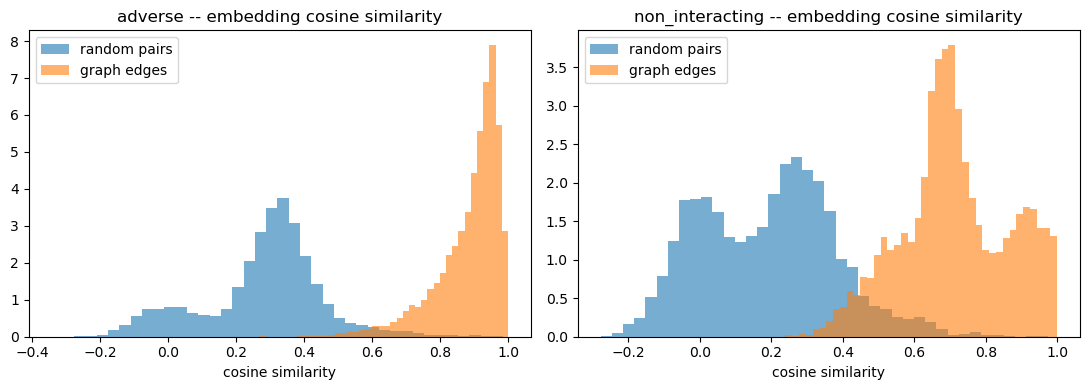

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, dataset in zip(axes, graphs):
    pos_sims, neg_sims = similarity_samples[dataset]
    ax.hist(neg_sims, bins=40, alpha=0.6, density=True, label="random pairs")
    ax.hist(pos_sims, bins=40, alpha=0.6, density=True, label="graph edges")
    ax.set_title(f"{dataset} -- embedding cosine similarity")
    ax.set_xlabel("cosine similarity")
    ax.legend()
plt.tight_layout()
plt.show()

### 6a. Is the high `auroc_edge_vs_random` actually "more meaning," or just node2vec doing its job?

Section 6 shows embeddings separate **graph edges** from random pairs almost perfectly (AUROC ~0.99). That is expected and somewhat tautological -- reproducing the input graph's own edges is *exactly* what node2vec is trained to do, so a high score there mainly confirms training worked, not that anything new was discovered.

The more meaningful question is whether embedding similarity is *more* predictive of **real adverse DDI status** than the raw ATC similarity score was. `network_generation.ipynb` already measured this for the raw score: `auroc_ddi_prediction = 0.538` (barely better than chance) -- known adverse DDI pairs vs. random pairs, scored by the raw ATC similarity that fed into the graph. We recompute the same comparison here, scored by embedding cosine similarity instead, using the **full curated adverse DDI pair list** (not just the pairs that survived sparsification into graph edges) so it's an apples-to-apples comparison against that 0.538 baseline.

In [10]:
adverse_atc_df = pd.read_parquet(r"C:\Users\ashto\ddi-prediction\notebooks\h2_pharmacological_similarity\adverse_atc_sim.parquet")

emb = atc_embeddings["adverse"]
node_ids = list(emb.index)
id_set = set(node_ids)
id_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
normed = emb.values / np.linalg.norm(emb.values, axis=1, keepdims=True)

# use the full curated adverse DDI pair list, not just the pairs that survived sparsification into graph edges
ddi_pairs = [
    (u, v) for u, v in zip(adverse_atc_df["drug1_id"], adverse_atc_df["drug2_id"])
    if u in id_set and v in id_set
]
ddi_sims = np.array([normed[id_to_idx[u]] @ normed[id_to_idx[v]] for u, v in ddi_pairs])

known_ddi_set = {frozenset(pair) for pair in ddi_pairs}
n_nodes = len(node_ids)
random_sims = []
while len(random_sims) < len(ddi_pairs):
    i, j = rng.integers(0, n_nodes, size=2)
    if i == j:
        continue
    u, v = node_ids[i], node_ids[j]
    if frozenset((u, v)) in known_ddi_set:
        continue
    random_sims.append(normed[i] @ normed[j])
random_sims = np.array(random_sims)

y_true = np.concatenate([np.ones(len(ddi_sims)), np.zeros(len(random_sims))])
y_score = np.concatenate([ddi_sims, random_sims])
embedding_ddi_auroc = roc_auc_score(y_true, y_score)

print(f"n known adverse DDI pairs (both drugs embedded): {len(ddi_pairs)}")
print(f"AUROC -- embedding cosine similarity predicting known adverse DDI pairs vs. random: {embedding_ddi_auroc:.3f}")
print("AUROC -- raw ATC similarity predicting the same (from network_generation.ipynb):      0.538")

n known adverse DDI pairs (both drugs embedded): 471895
AUROC -- embedding cosine similarity predicting known adverse DDI pairs vs. random: 0.646
AUROC -- raw ATC similarity predicting the same (from network_generation.ipynb):      0.538


## 7. Load the combined graph and train the canonical embedding (for downstream modeling)

The two embedding tables saved in Section 5 (`adverse_atc_node2vec.parquet`, `non_interacting_atc_node2vec.parquet`) are useful for the diagnostics above, but they **cannot** be used directly as classifier features: each came from a separately-trained node2vec model, and skip-gram embeddings have no canonical coordinate system -- two independent training runs converge to arbitrary, unaligned vector spaces. A classifier fed "adverse rows get vectors from model A, non_interacting rows get vectors from model B" could trivially separate the classes by detecting which arbitrary space a vector came from, not by learning real structural signal -- and at prediction time for a genuinely new pair, there's no way to know *which* graph's embedding to use without already knowing the label you're trying to predict.

The fix: `network_generation.ipynb` already built `combined_atc.graphml` from the union of both pair populations (edge weights are still just the raw, label-agnostic ATC similarity score). We just load it here, train node2vec on it once, and save that as the single embedding table any downstream classifier notebook should load.

In [11]:
G_combined = nx.read_graphml(NETWORK_DIR / "combined_atc.graphml")

n_isolates = sum(1 for _, deg in G_combined.degree() if deg == 0)
print(f"Combined graph: {G_combined.number_of_nodes():,} nodes, {G_combined.number_of_edges():,} edges, "
      f"{n_isolates} isolate(s), density={nx.density(G_combined):.5f}")

Combined graph: 1,893 nodes, 15,570 edges, 27 isolate(s), density=0.00869


In [12]:
combined_embeddings = run_node2vec(G_combined, **NODE2VEC_PARAMS)
print(f"Combined embeddings shape: {combined_embeddings.shape}")

save_embeddings(combined_embeddings, EMBEDDING_DIR / "combined_atc_node2vec.parquet")
print(f"Saved to {EMBEDDING_DIR / 'combined_atc_node2vec.parquet'} -- use this file for any downstream classifier.")

Combined embeddings shape: (1893, 128)
Saved to C:\Users\ashto\ddi-prediction\notebooks\h2_pharmacological_similarity\embeddings\combined_atc_node2vec.parquet -- use this file for any downstream classifier.


## 8. Sanity-check the combined embedding

Same checks as Sections 4 and 6, but run against `G_combined` / `combined_embeddings` -- this is the artifact downstream classifiers actually consume, so it should pass the same missing-node, PCA-collapse, nearest-neighbor, and edge-vs-random AUROC checks as the per-population embeddings did.

combined        : 0 node(s) missing an embedding (expect 0)


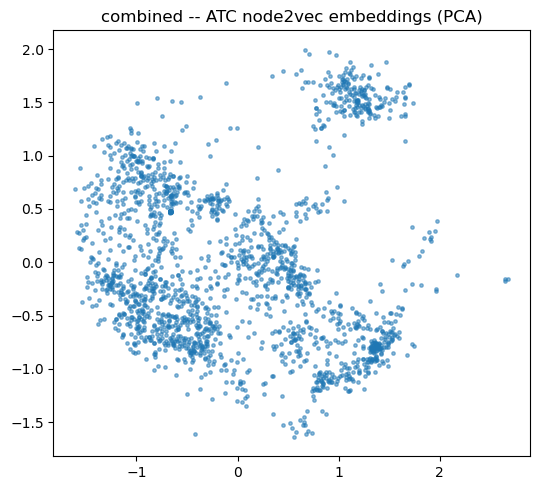


Nearest embedding neighbors of DB00909 (Zonisamide):
  DB05541 (Brivaracetam): cosine_sim=0.807, direct graph edge=True
  DB06218 (Lacosamide): cosine_sim=0.799, direct graph edge=True
  DB01121 (Phenacemide): cosine_sim=0.797, direct graph edge=True
  DB08883 (Perampanel): cosine_sim=0.792, direct graph edge=True
  DB06119 (Cenobamate): cosine_sim=0.790, direct graph edge=True

combined        : mean_cos_sim_edges=0.856, mean_cos_sim_random_pairs=0.317, auroc_edge_vs_random=0.992


In [14]:
n_missing = G_combined.number_of_nodes() - combined_embeddings.shape[0]
print(f"combined        : {n_missing} node(s) missing an embedding (expect 0)")

fig, ax = plt.subplots(figsize=(5.5, 5))
coords = PCA(n_components=2, random_state=42).fit_transform(combined_embeddings.values)
ax.scatter(coords[:, 0], coords[:, 1], s=6, alpha=0.5)
ax.set_title("combined -- ATC node2vec embeddings (PCA)")
plt.tight_layout()
plt.show()

sample_node = max(G_combined.degree, key=lambda x: x[1])[0]  # pick a well-connected node so its neighbors are informative
sims = cosine_similarity(combined_embeddings.loc[[sample_node]], combined_embeddings).flatten()
nearest = pd.Series(sims, index=combined_embeddings.index).drop(sample_node).sort_values(ascending=False).head(5)

sample_name = G_combined.nodes[sample_node].get("name", sample_node)
print(f"\nNearest embedding neighbors of {sample_node} ({sample_name}):")
for neighbor_id, sim in nearest.items():
    is_graph_neighbor = G_combined.has_edge(sample_node, neighbor_id)
    neighbor_name = G_combined.nodes[neighbor_id].get("name", neighbor_id)
    print(f"  {neighbor_id} ({neighbor_name}): cosine_sim={sim:.3f}, direct graph edge={is_graph_neighbor}")

# edge-vs-random AUROC, same recipe as Section 6, scored against the combined graph's own edges
node_ids = list(combined_embeddings.index)
id_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
normed = combined_embeddings.values / np.linalg.norm(combined_embeddings.values, axis=1, keepdims=True)

edges = list(G_combined.edges())
pos_sims = np.array([normed[id_to_idx[u]] @ normed[id_to_idx[v]] for u, v in edges])

n_nodes = len(node_ids)
neg_sims = []
while len(neg_sims) < len(edges):
    i, j = rng.integers(0, n_nodes, size=2)
    if i == j:
        continue
    u, v = node_ids[i], node_ids[j]
    if G_combined.has_edge(u, v):
        continue
    neg_sims.append(normed[i] @ normed[j])
neg_sims = np.array(neg_sims)

y_true = np.concatenate([np.ones(len(pos_sims)), np.zeros(len(neg_sims))])
y_score = np.concatenate([pos_sims, neg_sims])

print(f"\ncombined        : mean_cos_sim_edges={pos_sims.mean():.3f}, "
      f"mean_cos_sim_random_pairs={neg_sims.mean():.3f}, "
      f"auroc_edge_vs_random={roc_auc_score(y_true, y_score):.3f}")

## Conclusions & recommendations (from the executed run)

### Conclusions

1. **node2vec clearly learned the graph structure.** `auroc_edge_vs_random` is **0.995** (adverse) and **0.981** (non_interacting) -- embedding cosine similarity almost perfectly separates real ATC-graph edges from random drug pairs. This is the core sanity check for this notebook: it confirms the walk simulation + skip-gram training actually captured the ATC similarity graph's neighborhood structure, so the embeddings are safe to use as features downstream.
2. **Edges are noticeably "tighter" in the adverse graph than the non_interacting graph** -- mean cosine similarity of connected pairs is **0.88** (adverse) vs. **0.71** (non_interacting), and the histograms show the non_interacting graph's random-pair similarities are also more spread out (a visible second hump around 0.2-0.3 instead of a clean single peak near 0). This lines up with the `network_generation.ipynb` diagnostics, which found the non_interacting graph has a much higher isolate rate (22.3% vs. 9.9%) and a sparser edge set (5,126 vs. 13,718 edges) at the same `K_NEIGHBORS`/`MIN_SIMILARITY` settings -- a patchier, more fragmented graph gives node2vec less redundant path structure to learn consistent neighborhoods from.
3. **`auroc_edge_vs_random` (0.995) is a structural sanity check, not a DDI-predictiveness check -- and Section 6a shows the two give very different answers.** Reproducing the input graph's own edges is *exactly* what node2vec is optimized to do, so 0.995 mainly confirms training worked, not that anything new was "discovered." The question that actually matters -- does embedding similarity predict **real adverse DDI status** better than the raw ATC similarity score did -- gets a much more modest answer: AUROC **0.646** using embeddings vs. **0.538** using the raw score (both measured against the same full curated adverse-pair list, from `network_generation.ipynb`'s own diagnostic). So node2vec *is* extracting real additional signal here (+0.11 AUROC, not nothing), but it's a moderate improvement over a weak baseline, not the dramatic "0.99-level" separation Section 6 might suggest at first glance.
4. **Why the gap between 0.995 and 0.646 exists:** most of the 471k curated adverse pairs used in Section 6a never survived sparsification into an actual graph edge (only 13,718 pairs did, since `K_NEIGHBORS=15` per drug). For those non-edge pairs, embedding similarity relies entirely on indirect signal (shared multi-hop neighborhoods from random walks), not a direct trained-on connection -- so it's naturally a weaker signal than "am I directly reproducing an edge I was trained on," but it's also a fairer test of whether the embeddings generalize beyond their literal training edges.

### Recommendations

1. Treat these embeddings as validated for structural fidelity -- they're ready to feed into the downstream DDI feature table (`merging_into_final_drug_pair_feature_table.ipynb`) alongside the H1/H3 embeddings, but budget for the fact that ATC-based embeddings alone are only a moderate (not strong) DDI signal (AUROC ~0.65) -- consistent with `network_generation.ipynb`'s conclusion that ATC similarity works best as a complementary feature alongside H1's biological-overlap and H3's structural embeddings, not a standalone predictor.
2. Given the non_interacting graph's weaker/patchier embedding separation, consider re-running node2vec on it with more walks per node (`num_walks`) or a longer `walk_length` to compensate for its higher isolate rate and sparser connectivity, rather than assuming the same hyperparameters are equally well-suited to both graphs.
3. Re-run this same Section 6 check after any future re-tuning of `K_NEIGHBORS`/`MIN_SIMILARITY` in `network_generation.ipynb`, or after changing `NODE2VEC_PARAMS` here -- it's a cheap way to catch a degenerate embedding run (e.g. `auroc_edge_vs_random` near 0.5 would mean node2vec failed to learn anything useful) before spending time downstream.
4. When the downstream modeling notebook evaluates feature importance, re-run Section 6a's methodology (embedding similarity vs. known DDI pairs) for the H1/H3 embeddings too, so all three hypotheses' embeddings get compared on the same real-world-predictiveness basis rather than just the structural-fidelity check.